In [33]:
from scipy import stats
import pandas as pd
import os, pickle
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
consensus_pkl_file = r"D:\Projects\whakaari\output_train_1_2_3_RF_ER_4\predictions\fm_2.00_0.75_2.00_dsar-hf-mf-rsam_hires\consensus.pkl"
_file = open(consensus_pkl_file, "rb")
df = pickle.load(_file)

In [35]:
df

,consensus
time,
2025-06-01 00:00:00,0.210
2025-06-01 00:10:00,0.178
2025-06-01 00:20:00,0.178
2025-06-01 00:30:00,0.252
2025-06-01 00:40:00,0.248
...,...
2025-06-29 23:10:00,0.000
2025-06-29 23:20:00,0.000
2025-06-29 23:30:00,0.000


In [36]:
# df['consensus'] = df[(df['consensus'] > 0.2) & (df['consensus'] < 0.87)]

In [38]:
df['distance_bin'] = pd.cut(df['consensus'], bins=120)

In [39]:
df.index[-1]

Timestamp('2025-06-29 23:50:00')

In [40]:
df.groupby("distance_bin", observed=False).count()

,consensus
distance_bin,
"(-0.000974, 0.00812]",1563
"(0.00812, 0.0162]",580
"(0.0162, 0.0243]",372
"(0.0243, 0.0325]",178
"(0.0325, 0.0406]",131
...,...
"(0.933, 0.942]",0
"(0.942, 0.95]",0
"(0.95, 0.958]",0


In [41]:
pivot_df = pd.pivot_table(df, values='consensus', index='distance_bin', columns='consensus', aggfunc="count")
pivot_df

C:\Users\Anto\AppData\Local\Temp\ipykernel_30224\1156515969.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_df = pd.pivot_table(df, values='consensus', index='distance_bin', columns='consensus', aggfunc="count")


consensus
distance_bin
"(-0.000974, 0.00812]"
"(0.00812, 0.0162]"
"(0.0162, 0.0243]"
"(0.0243, 0.0325]"
"(0.0325, 0.0406]"
...
"(0.933, 0.942]"
"(0.942, 0.95]"
"(0.95, 0.958]"


In [42]:
mean = df['consensus'].mean()
std = df['consensus'].std()
ymin = df['consensus'].min()
ymax = df['consensus'].max()

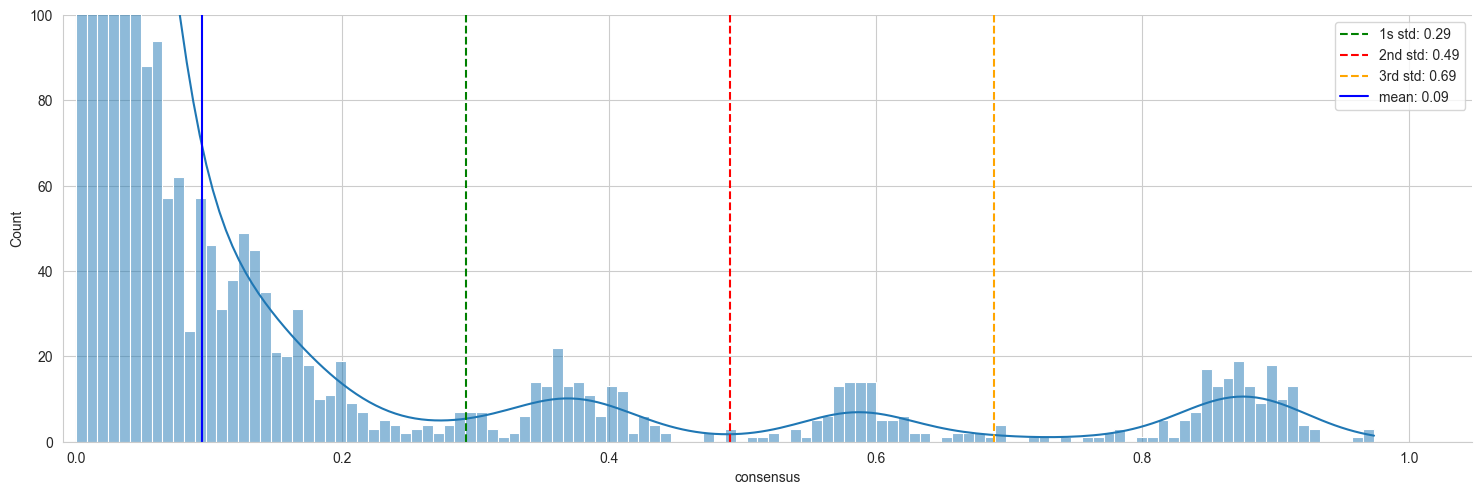

In [46]:
sns.displot(df['consensus'], bins=120,kde=True, aspect=3)
plt.axvline(mean+std, color='g', linestyle='dashed', label=f"1s std: {mean+(std):.2f}")
plt.axvline(mean+(std*2), color='red', linestyle='dashed', label=f"2nd std: {mean+(std*2):.2f}")
plt.axvline(mean+(std*3), color='orange', linestyle='dashed', label=f"3rd std: {mean+(std*3):.2f}")
plt.axvline(mean-std, color='g', linestyle='dashed')
plt.axvline(mean-(std*2), color='red', linestyle='dashed')
plt.axvline(mean-(std*3), color='orange', linestyle='dashed')
plt.axvline(mean, color='b', label=f'mean: {mean:.2f}')
plt.xlim(-0.01)
plt.ylim([0, 100])

plt.legend()

In [ ]:


fig, ax = plt.subplots(figsize=(12,3))
ax.hist(df['consensus'], bins=30, color='k', edgecolor='white', alpha=0.5, density=True)

ax.axvline(mean+std, color='g', linestyle='dashed', label='mean+std')
ax.axvline(mean+(std*2), color='red', linestyle='dashed', label='mean+std*2')
ax.axvline(mean+(std*3), color='yellow', linestyle='dashed', label='mean+std*3')
ax.axvline(mean-std, color='g', linestyle='dashed')
ax.axvline(mean-(std*2), color='red', linestyle='dashed')
ax.axvline(mean-(std*3), color='yellow', linestyle='dashed')
ax.axvline(mean, color='b', label='mean')

# ax.set_ylim(ymin, ymax)

ax.legend()

In [ ]:
df['z_score'].plot()